<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Neural Networks (NN) - MLP Modeling
</p>


## Purpose and evaluation protocol

This notebook implements a time-aware ANN (MLP) pipeline for path loss prediction. The evaluation design follows strict temporal separation to avoid leakage.

Key principles:
- Train/test split is time-ordered (train window precedes test window).
- Model selection is done via time-aware cross-validation on the training window only.
- Feature scaling is fit on the training window and applied to validation/test.
- The held-out test window is used once for final reporting.

Metrics reported: MSE, MAE, RMSE, R2, MAPE, Median AE.


In [1]:
# Imports - core utils, data wrangling, ANN modeling, evaluation, and plotting

# Standard library
import ast
import os
import pickle
import re
import time

# Data handling
import numpy as np
import pandas as pd
from IPython.display import display

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.colors import qualitative
from plotly.subplots import make_subplots

# TensorFlow / Keras
import tensorflow as tf
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import BatchNormalization, Dense, Dropout, Input, LeakyReLU
from keras.models import Sequential
from keras.regularizers import l2
from tensorflow.keras import backend as K

# ML evaluation and splitting
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
)
from sklearn.preprocessing import StandardScaler

# Reproducibility
GLOBAL_SEED = 50
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Data and Preprocessing
</p>


In [2]:
# Paths 
TRAIN_CSV = "Data_Files/train.csv"
TEST_CSV  = "Data_Files/test.csv"
FOLDS_NPY = "Data_Files/train_folds.npy"
CV_SPLITS_NPZ = "Data_Files/train_time_series_cv_splits.npz"

MODELS_DIR     = "Models"
FIGURES_DIR    = "Figures"
CV_RESULTS_DIR = "CV_Results"
RESIDUALS_DIR  = "Residuals"

for directory in [MODELS_DIR, FIGURES_DIR, CV_RESULTS_DIR, RESIDUALS_DIR]:
    os.makedirs(directory, exist_ok=True)

CV_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "ann_kfold_results_summary.csv")
MODEL_PATH      = os.path.join(MODELS_DIR, "ann_final_model.pkl")

# Load time-aware train/test split and predefined train folds
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)
fold_assignments = np.load(FOLDS_NPY)
fold_assignments = np.asarray(fold_assignments).ravel()
cv_npz = np.load(CV_SPLITS_NPZ)
n_splits = int(cv_npz["n_splits"])
cv_splits = [
    (cv_npz[f"fold_{i}_train_idx"], cv_npz[f"fold_{i}_val_idx"])
    for i in range(n_splits)
]


# Optional datetime parsing for reporting/saving
for df in [df_train, df_test]:
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")

if len(fold_assignments) != len(df_train):
    raise ValueError(
        f"fold_assignments length ({len(fold_assignments)}) does not match "
        f"df_train length ({len(df_train)})"
    )


def validate_cv_splits(cv_splits, fold_assignments, name="cv_splits"):
    fold_ids = sorted(np.unique(fold_assignments[fold_assignments >= 0]).astype(int).tolist())
    if len(cv_splits) != len(fold_ids):
        raise ValueError(f"{name} has {len(cv_splits)} splits but fold metadata has {len(fold_ids)} validation folds.")

    for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):
        tr_idx = np.asarray(tr_idx, dtype=int)
        val_idx = np.asarray(val_idx, dtype=int)
        if tr_idx.size == 0 or val_idx.size == 0:
            raise ValueError(f"{name} fold {fold_num} has an empty train or validation index set.")
        if np.intersect1d(tr_idx, val_idx).size:
            raise ValueError(f"{name} fold {fold_num} has train/validation overlap.")
        if tr_idx.max() >= val_idx.min():
            raise ValueError(f"{name} fold {fold_num} trains on rows at or after its validation window.")

        expected_val_idx = np.flatnonzero(fold_assignments == fold_num)
        if not np.array_equal(val_idx, expected_val_idx):
            raise ValueError(f"{name} fold {fold_num} validation indices do not match train_folds.npy metadata.")


validate_cv_splits(cv_splits, fold_assignments)

feature_columns = [
    "distance", "frequency", "c_walls", "w_walls",
    "co2", "humidity", "pm25", "pressure", "temperature", "snr"
]
target_column = "PL"

required_cols = [target_column, "device_id", *feature_columns]
missing_train = [c for c in required_cols if c not in df_train.columns]
missing_test  = [c for c in required_cols if c not in df_test.columns]

if missing_train or missing_test:
    raise ValueError(
        f"Missing columns | train: {missing_train} | test: {missing_test}"
    )

# Raw features only. Scaling is fit inside each CV fold or final training window.
X_train_df = df_train[feature_columns].copy()
X_test_df  = df_test[feature_columns].copy()

X_train = X_train_df.to_numpy()
X_test  = X_test_df.to_numpy()

PL_train_all = df_train[target_column].astype(float).to_numpy()
PL_test_all  = df_test[target_column].astype(float).to_numpy()
y_train = PL_train_all
y_test = PL_test_all

# Time-aware folds
# Hold out the most recent training fold for final early-stopping validation
fold_ids = np.unique(fold_assignments)
fold_ids = fold_ids[fold_ids >= 0]
if fold_ids.size == 0:
    raise ValueError("fold_assignments must contain at least one non-negative fold id.")

val_fold = fold_ids.max()
val_mask = fold_assignments == val_fold

X_train_time_raw = X_train[~val_mask]
y_train_time = PL_train_all[~val_mask]
X_val_time_raw = X_train[val_mask]
y_val_time = PL_train_all[val_mask]

print(f"Training samples: {len(df_train)}, Test samples: {len(df_test)}")
if "time" in df_train.columns and "time" in df_test.columns:
    print(f"Train window: {df_train.time.min()} -> {df_train.time.max()}")
    print(f"Test window:  {df_test.time.min()} -> {df_test.time.max()}")
print(f"Validation fold for final early stopping: {val_fold} (rows: {val_mask.sum()})")

unique, counts = np.unique(fold_assignments, return_counts=True)
print("Fold sizes:", dict(zip(unique.astype(int), counts.astype(int))))
print("Time-based split prepared; scaling is fit inside folds and on the final train window only.")


Training samples: 1663627, Test samples: 415907
Train window: 2024-10-01 00:01:07.420593+00:00 -> 2025-08-12 17:18:53.293125+00:00
Test window:  2025-08-12 17:19:02.126782+00:00 -> 2025-09-30 23:59:55.971870+00:00
Validation fold for final early stopping: 4 (rows: 277271)
Fold sizes: {np.int64(0): np.int64(554543), np.int64(1): np.int64(277271), np.int64(2): np.int64(277271), np.int64(3): np.int64(277271), np.int64(4): np.int64(277271)}
Time-based split prepared; scaling is fit inside folds and on the final train window only.


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Model Definition
</p>


In [3]:
# Flexible model creation function

def create_ann_model(layer_units, input_dim, 
                     l2_reg=1e-4, 
                     dropout_rate=0.1, 
                     negative_slope=0.1):
    '''
    Creates an ANN model for regression with configurable architecture and 
    hyperparameters like L2 regularization, dropout, and LeakyReLU slope.
    
    Arguments:
        layer_units    : list of integers (e.g., [64, 32]) specifying 
                         the number of neurons in each hidden layer
        input_dim      : int, dimension of the input layer
        l2_reg         : float, L2 regularization factor
        dropout_rate   : float, dropout rate
        negative_slope : float, negative slope for LeakyReLU
    Returns:
        model          : Compiled Keras Sequential model
    '''
    model = Sequential()

    # Explicit input layer
    model.add(Input(shape=(input_dim,)))  

    # Add hidden layers based on the list of units
    for units in layer_units:
        model.add(Dense(units, kernel_regularizer=l2(l2_reg)))
        model.add(LeakyReLU(negative_slope=negative_slope))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    
    # Output layer for regression
    model.add(Dense(1, activation='linear'))

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    
    return model

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Architecture Grid
</p>


In [4]:
def build_architectures():
    archs = []

    # 1-layer
    for h1 in [8, 16, 32, 64, 128]:
        archs.append({"name": f"L1_{h1}", "units": [h1]})

    # 2-layer funnels
    for h1, h2 in [(32, 16), (64, 32), (128, 64), (64, 16), (128, 32)]:
        archs.append({"name": f"L2_{h1}_{h2}", "units": [h1, h2]})

    # 3-layer funnels
    for h1, h2, h3 in [(32, 16, 8), (64, 32, 16), (128, 64, 32), (64, 16, 8), (128, 32, 16)]:
        archs.append({"name": f"L3_{h1}_{h2}_{h3}", "units": [h1, h2, h3]})

    # Mauricio-style anchor (not copied, just a reasonable funnel)
    archs.append({"name": "L3_20_10_5", "units": [20, 10, 5]})

    return archs

architectures = build_architectures()
len(architectures), architectures[:5]

(16,
 [{'name': 'L1_8', 'units': [8]},
  {'name': 'L1_16', 'units': [16]},
  {'name': 'L1_32', 'units': [32]},
  {'name': 'L1_64', 'units': [64]},
  {'name': 'L1_128', 'units': [128]}])

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Time-Aware Cross-Validation (Model Selection)
</p>


In [5]:
t0 = time.time()

# Time-aware cross-validation for each architecture
kfold_results = []
n_splits = len(cv_splits)

for arch in architectures:
    print(f"Performing {n_splits}-Fold CV for Architecture: {arch['name']}")
    fold_metrics = []

    for fold_num, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        print(f"  Fold {fold_num}/{n_splits}...")

        # Split raw data to avoid scaling leakage
        X_train_fold_raw, X_val_fold_raw = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = PL_train_all[train_idx], PL_train_all[val_idx]

        # Fold-wise scaling: fit only on current train fold
        scaler_fold = StandardScaler()
        X_train_fold = scaler_fold.fit_transform(X_train_fold_raw)
        X_val_fold = scaler_fold.transform(X_val_fold_raw)

        K.clear_session()
        tf.random.set_seed(GLOBAL_SEED + fold_num)

        model_cv = create_ann_model(
            layer_units=arch["units"],
            input_dim=X_train_fold.shape[1],
            l2_reg=0.001,
            dropout_rate=0.3,
            negative_slope=0.1,
        )

        early_stop_cv = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
        reduce_lr_cv = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0)

        model_cv.fit(
            X_train_fold,
            y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=100,
            batch_size=128,
            verbose=0,
            callbacks=[early_stop_cv, reduce_lr_cv],
        )

        val_loss_cv, val_mae_cv = model_cv.evaluate(X_val_fold, y_val_fold, verbose=0)
        val_pred = model_cv.predict(X_val_fold, verbose=0).flatten()

        rmse_cv = np.sqrt(mean_squared_error(y_val_fold, val_pred))
        r2_cv = r2_score(y_val_fold, val_pred)
        mape_cv = mean_absolute_percentage_error(y_val_fold, val_pred) * 100
        median_ae_cv = median_absolute_error(y_val_fold, val_pred)

        fold_metrics.append({
            "Fold": fold_num,
            "Val MSE": val_loss_cv,
            "Val MAE": val_mae_cv,
            "Val RMSE": rmse_cv,
            "R2 Score": r2_cv,
            "Val MAPE (%)": mape_cv,
            "Val Median AE": median_ae_cv,
        })

        print(
            f" Fold {fold_num} Metrics - Val MSE: {val_loss_cv:.4f} | "
            f"Val RMSE: {rmse_cv:.4f} | R2: {r2_cv:.4f} | MAPE: {mape_cv:.2f}%"
        )

    arch_cv_df = pd.DataFrame(fold_metrics)
    arch_cv_mean = arch_cv_df.mean(numeric_only=True)
    arch_cv_std = arch_cv_df.std(numeric_only=True)

    kfold_results.append({
        "Architecture": arch["name"],
        "Hidden Layers": str(arch["units"]),
        "Mean Val MSE": arch_cv_mean["Val MSE"],
        "Std Val MSE": arch_cv_std["Val MSE"],
        "Mean Val MAE": arch_cv_mean["Val MAE"],
        "Std Val MAE": arch_cv_std["Val MAE"],
        "Mean Val RMSE": arch_cv_mean["Val RMSE"],
        "Std Val RMSE": arch_cv_std["Val RMSE"],
        "Mean R2": arch_cv_mean["R2 Score"],
        "Std R2": arch_cv_std["R2 Score"],
        "Mean Val MAPE (%)": arch_cv_mean["Val MAPE (%)"],
        "Std Val MAPE (%)": arch_cv_std["Val MAPE (%)"],
        "Mean Val MedAE": arch_cv_mean["Val Median AE"],
        "Std Val MedAE": arch_cv_std["Val Median AE"],
    })

kfold_results_df = pd.DataFrame(kfold_results)
kfold_results_df_sorted = kfold_results_df.sort_values(by="Mean Val RMSE", ascending=True)
print("\nTime-aware CV summary (sorted by Mean Val RMSE):")
display(kfold_results_df_sorted.head())

kfold_results_df_sorted.to_csv(CV_RESULTS_PATH, index=False)
print(f"\nCV results saved to: {CV_RESULTS_PATH}")

# Select the best architecture by CV
best_arch_name = kfold_results_df_sorted.iloc[0]["Architecture"]
best_arch_units = next(a["units"] for a in architectures if a["name"] == best_arch_name)
print(f"\nSelected architecture: {best_arch_name} with layers {best_arch_units}")

t1 = time.time()
print(f"\nANN CV complete in {(t1 - t0) / 60:.2f} minutes.")


Performing 5-Fold CV for Architecture: L1_8
  Fold 1/5...
 Fold 1 Metrics - Val MSE: 47.3372 | Val RMSE: 6.8790 | R2: 0.8679 | MAPE: 5.98%
  Fold 2/5...
 Fold 2 Metrics - Val MSE: 58.4447 | Val RMSE: 7.6437 | R2: 0.8374 | MAPE: 6.93%
  Fold 3/5...
 Fold 3 Metrics - Val MSE: 58.4225 | Val RMSE: 7.6416 | R2: 0.8174 | MAPE: 6.54%
  Fold 4/5...
 Fold 4 Metrics - Val MSE: 57.0448 | Val RMSE: 7.5516 | R2: 0.8575 | MAPE: 6.95%
  Fold 5/5...
 Fold 5 Metrics - Val MSE: 42.2647 | Val RMSE: 6.5000 | R2: 0.8701 | MAPE: 5.69%
Performing 5-Fold CV for Architecture: L1_16
  Fold 1/5...
 Fold 1 Metrics - Val MSE: 39.2864 | Val RMSE: 6.2656 | R2: 0.8904 | MAPE: 5.35%
  Fold 2/5...
 Fold 2 Metrics - Val MSE: 47.3457 | Val RMSE: 6.8793 | R2: 0.8683 | MAPE: 6.07%
  Fold 3/5...
 Fold 3 Metrics - Val MSE: 50.4916 | Val RMSE: 7.1042 | R2: 0.8421 | MAPE: 6.05%
  Fold 4/5...
 Fold 4 Metrics - Val MSE: 48.6926 | Val RMSE: 6.9760 | R2: 0.8784 | MAPE: 6.39%
  Fold 5/5...
 Fold 5 Metrics - Val MSE: 33.1000 | Val R

,Architecture,Hidden Layers,Mean Val MSE,Std Val MSE,Mean Val MAE,Std Val MAE,Mean Val RMSE,Std Val RMSE,Mean R2,Std R2,Mean Val MAPE (%),Std Val MAPE (%),Mean Val MedAE,Std Val MedAE
12,L3_128_64_32,"[128, 64, 32]",35.240871,4.047416,4.492468,0.292062,5.894776,0.347189,0.900790,0.012728,5.349478,0.372374,3.672056,0.294989
7,L2_128_64,"[128, 64]",35.797667,4.387375,4.550231,0.320814,5.947527,0.377435,0.898937,0.014074,5.433977,0.390424,3.723187,0.319180
8,L2_64_16,"[64, 16]",35.674749,5.201269,4.544452,0.390733,5.948532,0.443266,0.898935,0.014726,5.412753,0.518876,3.720591,0.420598
14,L3_128_32_16,"[128, 32, 16]",36.003845,4.632996,4.538443,0.347114,5.966312,0.386038,0.898440,0.012648,5.348896,0.426395,3.710975,0.395530
6,L2_64_32,"[64, 32]",35.925733,4.628560,4.566562,0.330565,5.970168,0.390416,0.898370,0.012035,5.441556,0.452974,3.739550,0.315553



CV results saved to: CV_Results/ann_kfold_results_summary.csv

Selected architecture: L3_128_64_32 with layers [128, 64, 32]

ANN CV complete in 162.75 minutes.


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Final Training and Test Evaluation
</p>


In [6]:
t2 = time.time()

# Fallback: load saved CV summary if this session did not just run the CV cell.
if "best_arch_units" not in locals() or "best_arch_name" not in locals():
    legacy_cv_result_paths = [
        os.path.join("ANN", "Results", "kfold_results_summary.csv"),
        os.path.join("Results", "kfold_results_summary.csv"),
    ]

    if os.path.exists(CV_RESULTS_PATH):
        kfold_results_df_sorted = pd.read_csv(CV_RESULTS_PATH)
    else:
        kfold_results_df_sorted = None
        for legacy_path in legacy_cv_result_paths:
            if os.path.exists(legacy_path):
                kfold_results_df_sorted = pd.read_csv(legacy_path)
                kfold_results_df_sorted.to_csv(CV_RESULTS_PATH, index=False)
                print(f"Migrated legacy ANN CV results to: {CV_RESULTS_PATH}")
                break

        if kfold_results_df_sorted is None:
            raise FileNotFoundError(
                f"No ANN CV results found. Run the CV cell or provide {CV_RESULTS_PATH}."
            )

    kfold_results_df_sorted = kfold_results_df_sorted.sort_values(by="Mean Val RMSE", ascending=True)
    best_arch_name = kfold_results_df_sorted.iloc[0]["Architecture"]
    best_arch_units = ast.literal_eval(kfold_results_df_sorted.iloc[0]["Hidden Layers"])
    print(f"Loaded selected architecture from CV results: {best_arch_name} with layers {best_arch_units}")

# Leak-free scaling for the final train/validation/test stage
X_train_time_raw = X_train[train_time_idx]
X_val_time_raw = X_train[val_time_idx]

scaler_final = StandardScaler()
X_train_time_scaled = scaler_final.fit_transform(X_train_time_raw)
X_val_time_scaled = scaler_final.transform(X_val_time_raw)
X_test_all_scaled = scaler_final.transform(X_test)

K.clear_session()
tf.random.set_seed(GLOBAL_SEED)

final_model = create_ann_model(
    layer_units=best_arch_units,
    input_dim=X_train_time_scaled.shape[1],
    l2_reg=0.001,
    dropout_rate=0.3,
    negative_slope=0.1,
)

early_stop = EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=0)

history_final = final_model.fit(
    X_train_time_scaled,
    y_train_time,
    validation_data=(X_val_time_scaled, y_val_time),
    epochs=500,
    batch_size=128,
    verbose=0,
    callbacks=[early_stop, reduce_lr],
)

# Held-out test evaluation
final_test_mse, final_test_mae = final_model.evaluate(X_test_all_scaled, PL_test_all, verbose=0)
PL_pred_test = final_model.predict(X_test_all_scaled, verbose=0).flatten()
resid_test = PL_test_all - PL_pred_test

final_test_rmse = np.sqrt(mean_squared_error(PL_test_all, PL_pred_test))
final_test_r2 = r2_score(PL_test_all, PL_pred_test)
final_test_mape = mean_absolute_percentage_error(PL_test_all, PL_pred_test) * 100
final_test_median_ae = median_absolute_error(PL_test_all, PL_pred_test)

# OOF predictions using the selected architecture
y_pred_oof = np.full(len(PL_train_all), np.nan, dtype=float)
if not cv_splits:
    raise ValueError("No validation splits found for OOF residual generation.")

for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):

    scaler_fold = StandardScaler()
    X_train_fold = scaler_fold.fit_transform(X_train[tr_idx])
    X_val_fold = scaler_fold.transform(X_train[val_idx])

    K.clear_session()
    tf.random.set_seed(GLOBAL_SEED + int(fold_num))

    fold_model = create_ann_model(
        layer_units=best_arch_units,
        input_dim=X_train_fold.shape[1],
        l2_reg=0.001,
        dropout_rate=0.3,
        negative_slope=0.1,
    )

    fold_early_stop = EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)
    fold_reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=0)

    fold_model.fit(
        X_train_fold,
        PL_train_all[tr_idx],
        validation_data=(X_val_fold, PL_train_all[val_idx]),
        epochs=500,
        batch_size=128,
        verbose=0,
        callbacks=[fold_early_stop, fold_reduce_lr],
    )

    y_pred_oof[val_idx] = fold_model.predict(X_val_fold, verbose=0).flatten()

mask = ~np.isnan(y_pred_oof)
PL_pred_oof = y_pred_oof[mask]
resid_oof = PL_train_all[mask] - PL_pred_oof

if mask.sum() != len(PL_train_all):
    print(f"OOF residuals generated for {mask.sum()} of {len(PL_train_all)} training rows.")

final_oof_rmse = np.sqrt(mean_squared_error(PL_train_all[mask], PL_pred_oof))
final_oof_r2 = r2_score(PL_train_all[mask], PL_pred_oof)

final_results_df = pd.DataFrame([
    {
        "Architecture": best_arch_name,
        "Hidden Layers": str(best_arch_units),
        "OOF RMSE": final_oof_rmse,
        "OOF R2": final_oof_r2,
        "Test MSE": final_test_mse,
        "Test MAE": final_test_mae,
        "Test RMSE": final_test_rmse,
        "Test R2": final_test_r2,
        "Test MAPE (%)": final_test_mape,
        "Test Median AE": final_test_median_ae,
    }
])

print("Final ANN evaluation:")
display(final_results_df)

# Save final model bundle
ann_bundle = {
    "best_arch_name": best_arch_name,
    "best_arch_units": best_arch_units,
    "input_dim": int(final_model.input_shape[1]),
    "model_params": {"l2_reg": 0.001, "dropout_rate": 0.3, "negative_slope": 0.1},
    "model_weights": final_model.get_weights(),
    "scaler": scaler_final,
}
with open(MODEL_PATH, "wb") as f:
    pickle.dump(ann_bundle, f)

print(f"Saved ANN model bundle to: {MODEL_PATH}")

# TEST residuals
ann_test_df = pd.DataFrame({
    "model":       "ANN",
    "split":       "test",
    "row_id":      np.arange(len(df_test), dtype=int),
    "time":        df_test.get("time", pd.Series(index=df_test.index, dtype=float)).values,
    "device_id":   df_test["device_id"].values,
    "distance":    df_test["distance"].values,
    "frequency":   df_test["frequency"].values,
    "c_walls":     df_test["c_walls"].values,
    "w_walls":     df_test["w_walls"].values,
    "co2":         df_test["co2"].values,
    "humidity":    df_test["humidity"].values,
    "pm25":        df_test["pm25"].values,
    "pressure":    df_test["pressure"].values,
    "temperature": df_test["temperature"].values,
    "snr":         df_test["snr"].values,
    "PL_true":     PL_test_all,
    "PL_pred":     PL_pred_test,
    "resid_db":    resid_test,
})

test_residual_path = os.path.join(RESIDUALS_DIR, "residuals_ANN_test.csv")
ann_test_df.to_csv(test_residual_path, index=False)
print(f"[TEST] Saved ANN test residuals: {test_residual_path}")

# OOF residuals
ann_oof_df = pd.DataFrame({
    "model":       "ANN",
    "split":       "oof",
    "row_id":      np.arange(len(df_train), dtype=int)[mask],
    "fold":        fold_assignments.astype(int)[mask],
    "time":        df_train.get("time", pd.Series(index=df_train.index, dtype=float)).values[mask],
    "device_id":   df_train["device_id"].values[mask],
    "distance":    df_train["distance"].values[mask],
    "frequency":   df_train["frequency"].values[mask],
    "c_walls":     df_train["c_walls"].values[mask],
    "w_walls":     df_train["w_walls"].values[mask],
    "co2":         df_train["co2"].values[mask],
    "humidity":    df_train["humidity"].values[mask],
    "pm25":        df_train["pm25"].values[mask],
    "pressure":    df_train["pressure"].values[mask],
    "temperature": df_train["temperature"].values[mask],
    "snr":         df_train["snr"].values[mask],
    "PL_true":     PL_train_all[mask],
    "PL_pred":     PL_pred_oof,
    "resid_db":    resid_oof,
})

oof_residual_path = os.path.join(RESIDUALS_DIR, "residuals_ANN_oof.csv")
ann_oof_df.to_csv(oof_residual_path, index=False)
print(f"[OOF] Saved ANN OOF residuals: {oof_residual_path}")

t3 = time.time()
print(f"\nTask complete in {(t3 - t2) / 60:.2f} minutes.")


Final ANN evaluation:


,Architecture,Hidden Layers,OOF RMSE,OOF R2,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE (%),Test Median AE
0,L3_128_64_32,"[128, 64, 32]",5.920418,0.900993,23.544083,3.53921,4.829524,0.934207,4.108222,2.79392


Saved ANN model bundle to: Models/ann_final_model.pkl
[TEST] Saved ANN test residuals: Residuals/residuals_ANN_test.csv
[OOF] Saved ANN OOF residuals: Residuals/residuals_ANN_oof.csv

Task complete in 62.02 minutes.


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
ANN Architecture Performance Analysis
</p>

In [3]:
# Load ANN CV-summary results for plotting
legacy_cv_result_paths = [
    os.path.join("ANN", "Results", "kfold_results_summary.csv"),
    os.path.join("Results", "kfold_results_summary.csv"),
]

if os.path.exists(CV_RESULTS_PATH):
    model_results_df = pd.read_csv(CV_RESULTS_PATH)
else:
    model_results_df = None
    for legacy_path in legacy_cv_result_paths:
        if os.path.exists(legacy_path):
            model_results_df = pd.read_csv(legacy_path)
            model_results_df.to_csv(CV_RESULTS_PATH, index=False)
            print(f"Migrated legacy ANN CV results to: {CV_RESULTS_PATH}")
            break

    if model_results_df is None:
        raise FileNotFoundError(
            f"No ANN CV results found. Run the CV cell or provide {CV_RESULTS_PATH}."
        )

model_results_df

,Architecture,Hidden Layers,Mean Val MSE,Std Val MSE,Mean Val MAE,Std Val MAE,Mean Val RMSE,Std Val RMSE,Mean R2,Std R2,Mean Val MAPE (%),Std Val MAPE (%),Mean Val MedAE,Std Val MedAE
0,L3_128_64_32,"[128, 64, 32]",35.240871,4.047416,4.492468,0.292062,5.894776,0.347189,0.900790,0.012728,5.349478,0.372374,3.672056,0.294989
1,L2_128_64,"[128, 64]",35.797667,4.387375,4.550231,0.320814,5.947527,0.377435,0.898937,0.014074,5.433977,0.390424,3.723187,0.319180
2,L2_64_16,"[64, 16]",35.674749,5.201269,4.544452,0.390733,5.948532,0.443266,0.898935,0.014726,5.412753,0.518876,3.720591,0.420598
3,L3_128_32_16,"[128, 32, 16]",36.003845,4.632996,4.538443,0.347114,5.966312,0.386038,0.898440,0.012648,5.348896,0.426395,3.710975,0.395530
4,L2_64_32,"[64, 32]",35.925733,4.628560,4.566562,0.330565,5.970168,0.390416,0.898370,0.012035,5.441556,0.452974,3.739550,0.315553
5,L2_128_32,"[128, 32]",36.050242,4.376901,4.538921,0.329695,5.973315,0.369198,0.898233,0.012069,5.425980,0.428985,3.680139,0.347929
6,L3_64_32_16,"[64, 32, 16]",36.115453,4.392415,4.562408,0.329356,5.980236,0.372184,0.897908,0.013122,5.427235,0.452608,3.727676,0.370717
7,L2_32_16,"[32, 16]",36.603758,5.032710,4.615941,0.391465,6.030624,0.423969,0.896195,0.013900,5.473067,0.540029,3.795210,0.427069
8,L3_32_16_8,"[32, 16, 8]",37.086303,5.821281,4.667510,0.451728,6.064902,0.488093,0.894877,0.016339,5.553330,0.607844,3.854061,0.485749
9,L3_64_16_8,"[64, 16, 8]",37.590977,5.723187,4.725101,0.459912,6.101750,0.478904,0.893744,0.014946,5.642386,0.635075,3.949533,0.531848


In [4]:

# Define the function to sum hidden layers
def sum_hidden_layers(hidden_layers_str):
    # Convert string representation of list to an actual list
    hidden_layers = ast.literal_eval(hidden_layers_str)
    # Calculate and return the sum
    return sum(hidden_layers)
    
# Define a function to count the number of hidden layers
def count_hidden_layers(hidden_layers_str):
    # Convert string representation of list to an actual list
    hidden_layers = ast.literal_eval(hidden_layers_str)
    # Return the number of layers
    return len(hidden_layers)

# Apply the function to create 'Total Nodes' column
model_results_df['Total Nodes'] = model_results_df['Hidden Layers'].apply(sum_hidden_layers)

# Apply the function to create 'Number of Layers' column
model_results_df['Number of Layers'] = model_results_df['Hidden Layers'].apply(count_hidden_layers)

# Rename columns (your requested names)
model_results_df.rename(
    columns={
        "Mean Val RMSE": "Test RMSE",
        "Mean R2": "R2 Score",
        "Std Val RMSE": "Std RMSE"
    },
    inplace=True
)

model_results_df

,Architecture,Hidden Layers,Mean Val MSE,Std Val MSE,Mean Val MAE,Std Val MAE,Test RMSE,Std RMSE,R2 Score,Std R2,Mean Val MAPE (%),Std Val MAPE (%),Mean Val MedAE,Std Val MedAE,Total Nodes,Number of Layers
0,L3_128_64_32,"[128, 64, 32]",35.240871,4.047416,4.492468,0.292062,5.894776,0.347189,0.900790,0.012728,5.349478,0.372374,3.672056,0.294989,224,3
1,L2_128_64,"[128, 64]",35.797667,4.387375,4.550231,0.320814,5.947527,0.377435,0.898937,0.014074,5.433977,0.390424,3.723187,0.319180,192,2
2,L2_64_16,"[64, 16]",35.674749,5.201269,4.544452,0.390733,5.948532,0.443266,0.898935,0.014726,5.412753,0.518876,3.720591,0.420598,80,2
3,L3_128_32_16,"[128, 32, 16]",36.003845,4.632996,4.538443,0.347114,5.966312,0.386038,0.898440,0.012648,5.348896,0.426395,3.710975,0.395530,176,3
4,L2_64_32,"[64, 32]",35.925733,4.628560,4.566562,0.330565,5.970168,0.390416,0.898370,0.012035,5.441556,0.452974,3.739550,0.315553,96,2
5,L2_128_32,"[128, 32]",36.050242,4.376901,4.538921,0.329695,5.973315,0.369198,0.898233,0.012069,5.425980,0.428985,3.680139,0.347929,160,2
6,L3_64_32_16,"[64, 32, 16]",36.115453,4.392415,4.562408,0.329356,5.980236,0.372184,0.897908,0.013122,5.427235,0.452608,3.727676,0.370717,112,3
7,L2_32_16,"[32, 16]",36.603758,5.032710,4.615941,0.391465,6.030624,0.423969,0.896195,0.013900,5.473067,0.540029,3.795210,0.427069,48,2
8,L3_32_16_8,"[32, 16, 8]",37.086303,5.821281,4.667510,0.451728,6.064902,0.488093,0.894877,0.016339,5.553330,0.607844,3.854061,0.485749,56,3
9,L3_64_16_8,"[64, 16, 8]",37.590977,5.723187,4.725101,0.459912,6.101750,0.478904,0.893744,0.014946,5.642386,0.635075,3.949533,0.531848,88,3


In [5]:
# Sort by Test RMSE
model_results_df_sorted = model_results_df.sort_values(by='Test RMSE', ascending=True)

# Prepare customdata
custom_cols = ['R2 Score', 'Number of Layers', 'Hidden Layers']
customdata = model_results_df_sorted[custom_cols].values

# Auto color mapping for any number of layers
layers = sorted(model_results_df_sorted['Number of Layers'].unique())
palette = qualitative.Set2
color_map = {n: palette[i % len(palette)] for i, n in enumerate(layers)}
colors = model_results_df_sorted['Number of Layers'].map(color_map)

# Figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Test RMSE bars (colored by layer count) + black borders, no legend entry
fig.add_trace(
    go.Bar(
        x=model_results_df_sorted['Architecture'],
        y=model_results_df_sorted['Test RMSE'],
        name='Test RMSE',
        marker=dict(color=colors, line=dict(color='black', width=1)),
        text=model_results_df_sorted['Total Nodes'],
        hoverinfo='none',
        hovertemplate=(
            '<b>Architecture:</b> %{x}<br>'
            '<b>Test RMSE:</b> %{y:.2f}<br>'
            '<b>R² Score:</b> %{customdata[0]:.4f}<br>'
            '<b>Total Nodes:</b> %{text}<br>'
            '<b>Number of Layers:</b> %{customdata[1]}<br>'
            '<b>Hidden Layers:</b> %{customdata[2]}<br>'
            '<extra></extra>'
        ),
        customdata=customdata,
        showlegend=False,
    ),
    secondary_y=False,
)

# Legend entry for Test RMSE (black box)
fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode='markers',
        marker=dict(size=10, color='black', symbol='square-open', line=dict(color='black', width=1)),
        name='Test RMSE',
        showlegend=True,
    )
)

# Auto legend entries for each layer count
for n in layers:
    fig.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode='markers',
            marker=dict(size=10, color=color_map[n]),
            name=f'{n} Hidden Layer{"s" if n != 1 else ""}',
            showlegend=True,
        )
    )

# R² line on secondary axis (non-interactive)
fig.add_trace(
    go.Scatter(
        x=model_results_df_sorted['Architecture'],
        y=model_results_df_sorted['R2 Score'],
        name='R² Score',
        mode='lines+markers',
        line=dict(color='red', width=2),
        marker=dict(size=8),
        hoverinfo='skip',
    ),
    secondary_y=True,
)

# Axes + layout
fig.update_xaxes(
    title_text='Architecture',
    tickmode='array',
    tickvals=model_results_df_sorted['Architecture'],
    ticktext=model_results_df_sorted['Architecture'],
    tickangle=-45,
)
fig.update_yaxes(title_text='Test RMSE', secondary_y=False, color='blue')
fig.update_yaxes(title_text='R² Score', secondary_y=True, color='red')
fig.update_layout(
    title=dict(
        text='Interactive Test RMSE and R² Score for Neural Network Architectures',
        x=0.5,
        xanchor='center',
    ),
    barmode='group',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.1,
        xanchor='center',
        x=0.5,
        bgcolor='rgba(255,255,255,0.8)',
    ),
    hovermode='x unified',
)

fig.show()

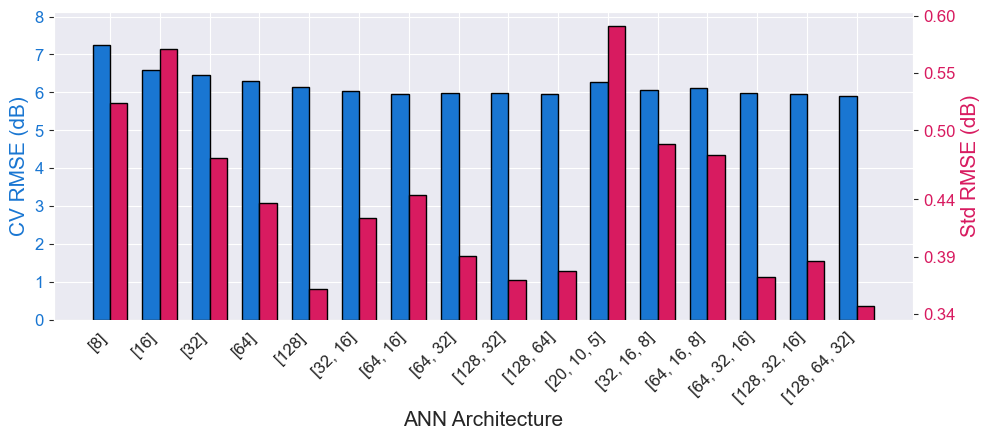

In [6]:
# FONT SIZES 
tick_fontsize = 12
axis_labelsize = 15

sns.set_style("darkgrid")

model_results_df_filtered_sorted = model_results_df_sorted.copy()
model_results_df_filtered_sorted["Total Nodes"] = pd.to_numeric(model_results_df_filtered_sorted["Total Nodes"], errors="coerce")
model_results_df_filtered_sorted["Number of Hidden Layers"] = model_results_df_filtered_sorted["Hidden Layers"].apply(lambda v: len(v) if isinstance(v, (list, tuple)) else len([x for x in str(v).replace("[", "").replace("]", "").replace("(", "").replace(")", "").split(",") if x.strip()]))

model_results_df_filtered_sorted = model_results_df_filtered_sorted.sort_values(by=["Number of Hidden Layers", "Total Nodes"], ascending=[True, True]).reset_index(drop=True)

x = np.arange(len(model_results_df_filtered_sorted))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 4.5))

rmse_color = "#1976d2"
std_color  = "#d81b60"

ax1.bar(x - bar_width/2, model_results_df_filtered_sorted["Test RMSE"], bar_width, color=rmse_color, edgecolor="black", linewidth=1, zorder=3)

ax1.set_xlabel("ANN Architecture", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels(model_results_df_filtered_sorted["Hidden Layers"], rotation=45, ha="right", fontsize=tick_fontsize)

ax1.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize, color=rmse_color)
ax1.tick_params(axis="y", labelcolor=rmse_color, labelsize=tick_fontsize)
ax1.grid(True, axis="y")
ax1.set_ylim(0, model_results_df_filtered_sorted["Test RMSE"].max() * 1.12)

ax2 = ax1.twinx()
ax2.bar(x + bar_width/2, model_results_df_filtered_sorted["Std RMSE"], bar_width, color=std_color, edgecolor="black", linewidth=1, zorder=3)

ax2.set_ylabel("Std RMSE (dB)", fontsize=axis_labelsize, color=std_color)
ax2.tick_params(axis="y", labelcolor=std_color, labelsize=tick_fontsize)
ax2.grid(False)

std = model_results_df_filtered_sorted["Std RMSE"].astype(float).to_numpy()
std_min, std_max = float(std.min()), float(std.max())
pad = 0.05 * (std_max - std_min) if std_max > std_min else 0.05
std_low, std_high = max(0.0, std_min - pad), std_max + pad

ax2.set_ylim(std_low, std_high)
ax2.set_yticks(np.round(np.linspace(std_low, std_high, 6), 2))

fig.tight_layout()
plt.show()

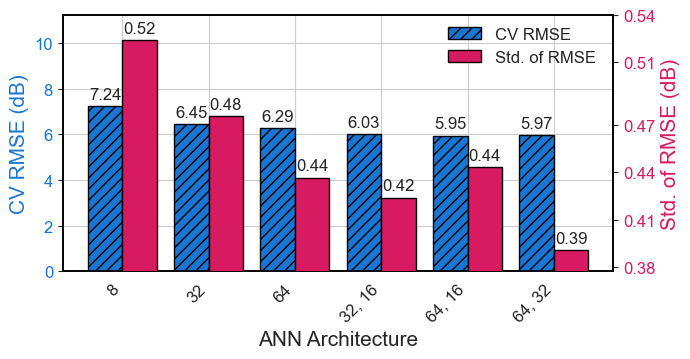

Saved figure: Figures\ANN_RMSE_STD_selected_archs.png


In [7]:
# FONT SIZE METRICS 
tick_fontsize   = 12
axis_labelsize  = 15
legend_fontsize = 12

# GLOBAL FONT FAMILY: Times New Roman 
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"

sns.set_style("whitegrid")

# target ANN architectures to keep 
TARGET_ARCHS = [
    (8,),
    (32,),
    (64,),
    (32, 16),
    (64, 16),
    (64, 32),
]

def arch_to_tuple(v):
    if isinstance(v, (list, tuple, np.ndarray)):
        return tuple(int(x) for x in v)
    nums = re.findall(r"\d+", str(v))
    return tuple(int(n) for n in nums)

def tuple_to_label(t):
    return ", ".join(map(str, t))

# filter + sort 
df_plot = model_results_df_sorted.copy()
df_plot["arch_tuple"] = df_plot["Hidden Layers"].apply(arch_to_tuple)
df_plot = df_plot[df_plot["arch_tuple"].isin(TARGET_ARCHS)].copy()
df_plot["Total Nodes"] = pd.to_numeric(df_plot["Total Nodes"], errors="coerce")
df_plot["Number of Hidden Layers"] = df_plot["arch_tuple"].apply(len)
df_plot = df_plot.sort_values(by=["Number of Hidden Layers", "Total Nodes"], ascending=[True, True]).reset_index(drop=True)
df_plot["arch_label"] = df_plot["arch_tuple"].apply(tuple_to_label)

if df_plot.empty:
    raise ValueError("No selected ANN architectures found for plotting.")

# twin-axis bars 
x = np.arange(len(df_plot))
bar_width = 0.40

fig, ax1 = plt.subplots(figsize=(7, 3.7))

rmse_color = "#1976d2"
std_color  = "#d81b60"

bars1 = ax1.bar(x - bar_width / 2, df_plot["Test RMSE"].astype(float), bar_width, color=rmse_color, edgecolor="black", linewidth=1, zorder=3)
for bar in bars1:
    bar.set_hatch("///")

ax1.set_xlabel("ANN Architecture", fontsize=axis_labelsize)
ax1.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize, color=rmse_color)
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot["arch_label"], rotation=45, ha="right", fontsize=tick_fontsize)
ax1.tick_params(axis="y", labelcolor=rmse_color, labelsize=tick_fontsize)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(x + bar_width / 2, df_plot["Std RMSE"].astype(float), bar_width, color=std_color, edgecolor="black", linewidth=1, zorder=3)
ax2.set_ylabel("Std. of RMSE (dB)", fontsize=axis_labelsize, color=std_color)
ax2.tick_params(axis="y", labelcolor=std_color, labelsize=tick_fontsize)
ax2.grid(False)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

ax1.bar_label(bars1, fmt="%.2f", padding=3, fontsize=tick_fontsize)
ax2.bar_label(bars2, fmt="%.2f", padding=3, fontsize=tick_fontsize)

ax1.set_ylim(0, float(df_plot["Test RMSE"].max()) * 1.55)

std = df_plot["Std RMSE"].astype(float).to_numpy()
std_min, std_max = float(std.min()), float(std.max())
pad = 0.10 * (std_max - std_min) if std_max > std_min else 0.10
std_low, std_high = max(0.0, std_min - pad), std_max + pad
ax2.set_ylim(std_low, std_high)
ax2.set_yticks(np.round(np.linspace(std_low, std_high, 6), 2))

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=rmse_color, edgecolor="black", hatch="///", label="CV RMSE"),
    plt.Rectangle((0, 0), 1, 1, facecolor=std_color, edgecolor="black", label="Std. of RMSE"),
]
leg = ax1.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.98, 0.98), borderaxespad=0.0, fontsize=legend_fontsize, frameon=False)

fig.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "ANN_RMSE_STD_selected_archs.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.show()
print(f"Saved figure: {fig_path}")